In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/loan_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
print("Shape of Dataset: ")
print(df.shape)

Shape of Dataset: 
(614, 13)


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [4]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
#approval and rejections

print(df["Loan_Status"].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [7]:
#per of app or rej

print(df["Loan_Status"].value_counts(normalize=True) * 100)

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [8]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


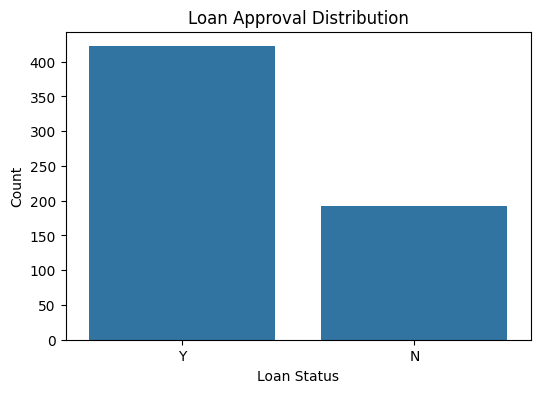

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="Loan_Status",
    data=df
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

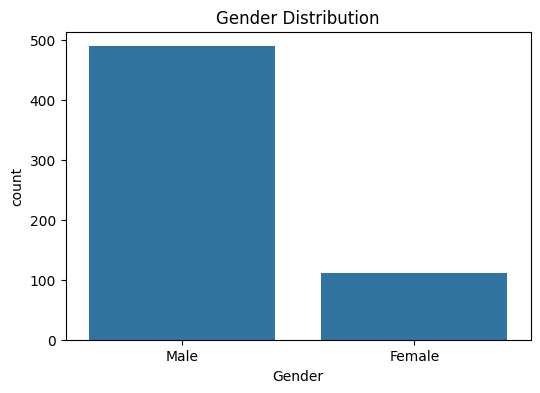

In [10]:
# gender based
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    data=df
)

plt.title("Gender Distribution")

plt.show()

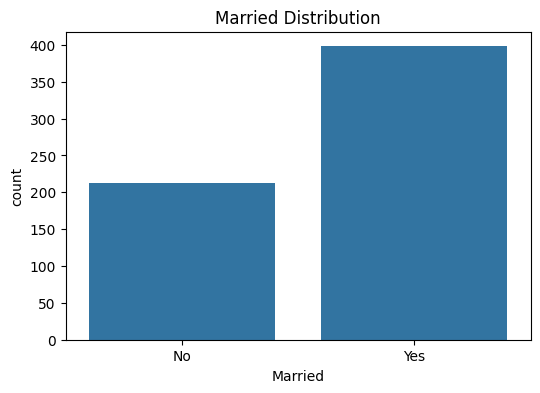

In [11]:
#relationship based
plt.figure(figsize=(6,4))

sns.countplot(
    x="Married",
    data=df
)

plt.title("Married Distribution")

plt.show()

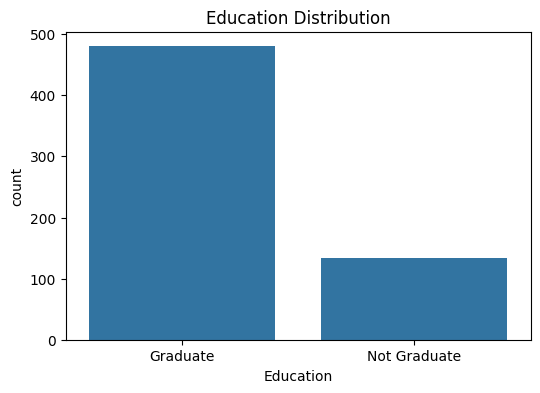

In [12]:
#education based
plt.figure(figsize=(6,4))

sns.countplot(
    x="Education",
    data=df
)

plt.title("Education Distribution")

plt.show()

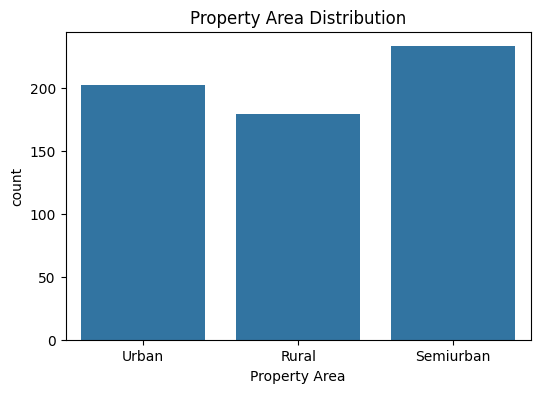

In [13]:
#property based 
plt.figure(figsize=(6,4))

sns.countplot(
    x="Property_Area",
    data=df
)

plt.title("Property Area Distribution")
plt.xlabel("Property Area")

plt.show()

In [14]:
# statistical summary
numerical_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

df[numerical_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


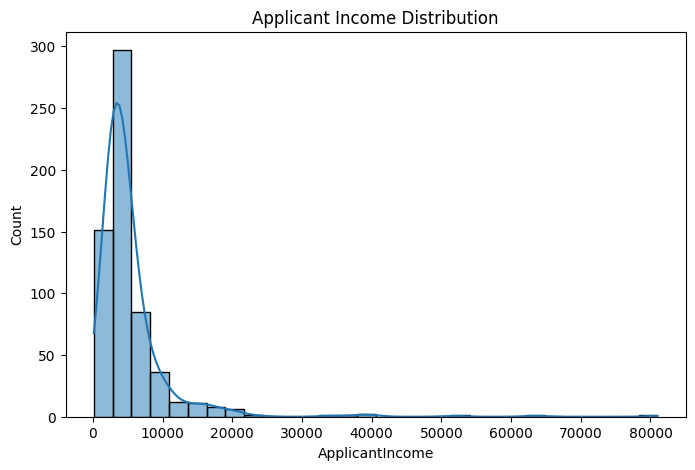

In [15]:
#histograms appn income
plt.figure(figsize=(8,5))

sns.histplot(
    df["ApplicantIncome"],
    bins=30,
    kde=True
)

plt.title("Applicant Income Distribution")

plt.savefig("../reports/figures/applicant_income_distribution.png")

plt.show()

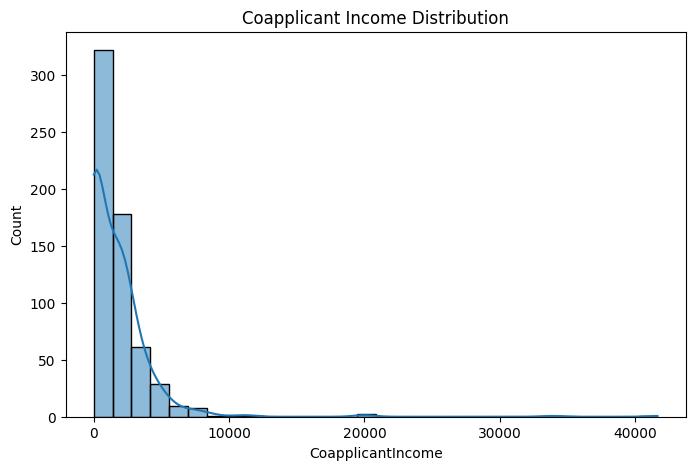

In [16]:
#coappn income
plt.figure(figsize=(8,5))

sns.histplot(
    df["CoapplicantIncome"],
    bins=30,
    kde=True
)

plt.title("Coapplicant Income Distribution")

plt.savefig("../reports/figures/coapplicant_income_distribution.png")

plt.show()

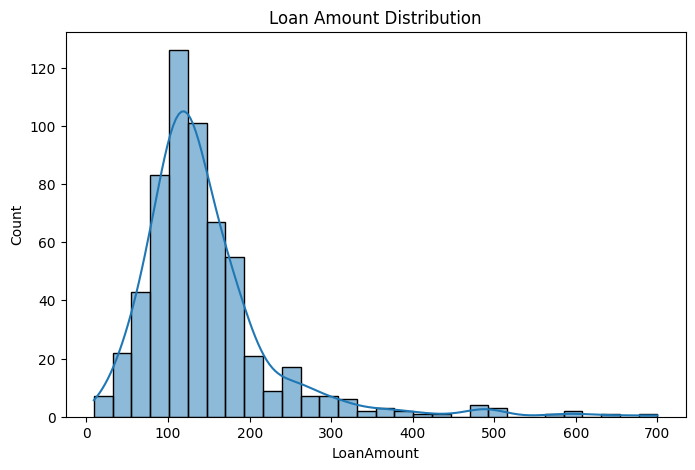

In [17]:
# loan amount 
plt.figure(figsize=(8,5))

sns.histplot(
    df["LoanAmount"],
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")

plt.savefig("../reports/figures/loan_amount_distribution.png")

plt.show()

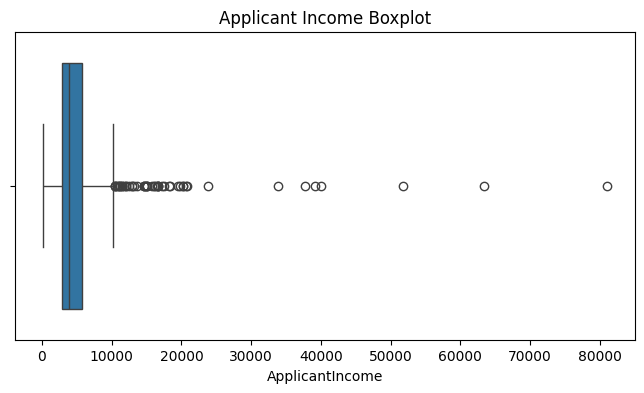

In [18]:
#box plot for outliers detection 
#Appn income
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["ApplicantIncome"]
)

plt.title("Applicant Income Boxplot")

plt.savefig("../reports/figures/applicant_income_boxplot.png")

plt.show()

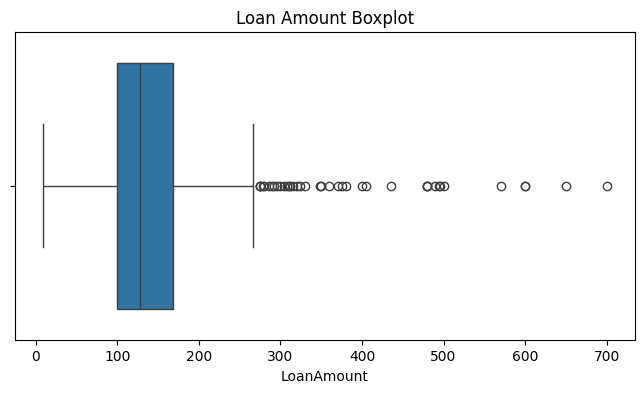

In [19]:
#loan amount
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["LoanAmount"]
)

plt.title("Loan Amount Boxplot")

plt.savefig("../reports/figures/loan_amount_boxplot.png")

plt.show()

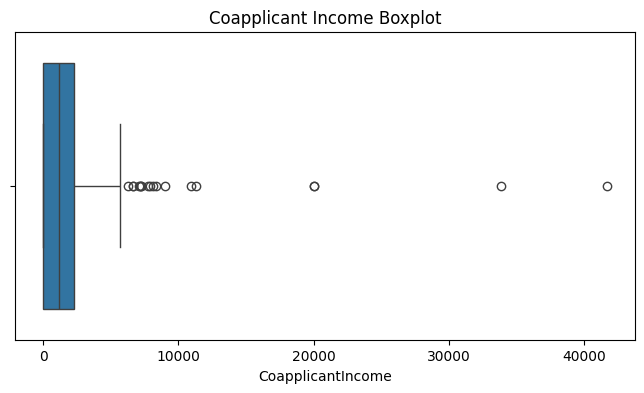

In [20]:
#coappn income
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["CoapplicantIncome"]
)

plt.title("Coapplicant Income Boxplot")

plt.savefig("../reports/figures/coapplicant_income_boxplot.png")

plt.show()

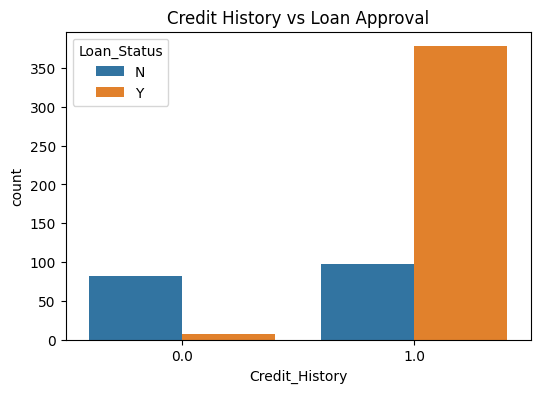

In [21]:
#approval vs credit
plt.figure(figsize=(6,4))

sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)

plt.title("Credit History vs Loan Approval")

plt.savefig("../reports/figures/credit_history_vs_approval.png")

plt.show()

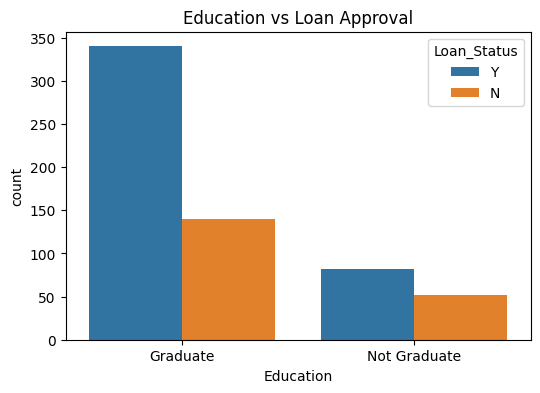

In [22]:
#approval vs edu
plt.figure(figsize=(6,4))

sns.countplot(
    x="Education",
    hue="Loan_Status",
    data=df
)

plt.title("Education vs Loan Approval")

plt.savefig("../reports/figures/education_vs_approval.png")

plt.show()

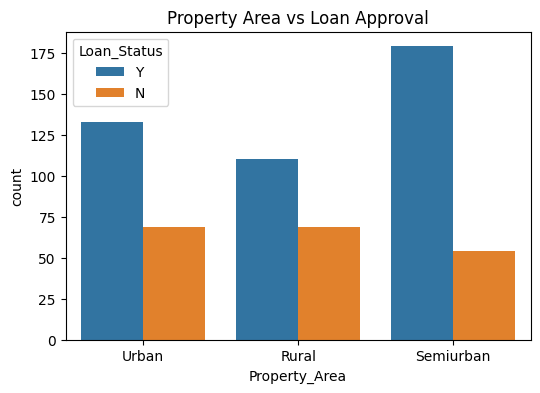

In [23]:
#approval vs property area 
plt.figure(figsize=(6,4))

sns.countplot(
    x="Property_Area",
    hue="Loan_Status",
    data=df
)

plt.title("Property Area vs Loan Approval")

plt.savefig("../reports/figures/property_area_vs_approval.png")

plt.show()

In [24]:
# null value percentages

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(
    ascending=False
)

Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Education            0.000000
Loan_ID              0.000000
CoapplicantIncome    0.000000
ApplicantIncome      0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

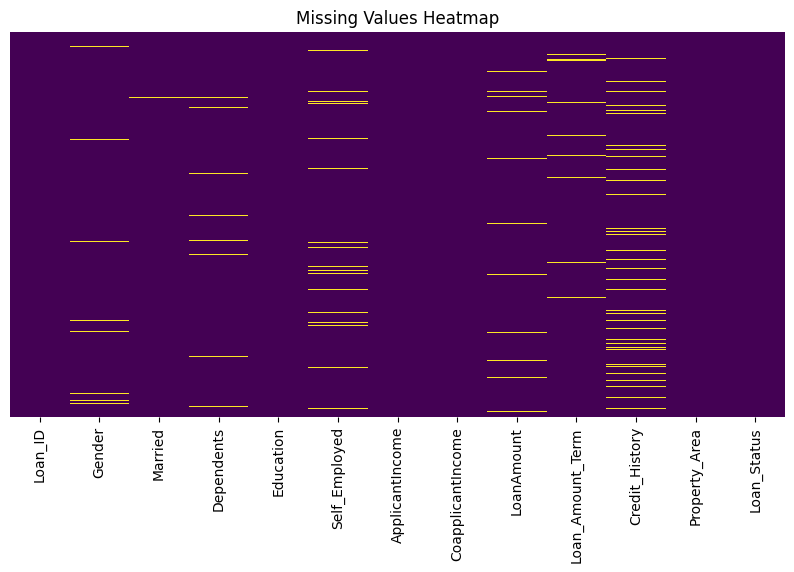

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [26]:
numerical_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

df[numerical_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


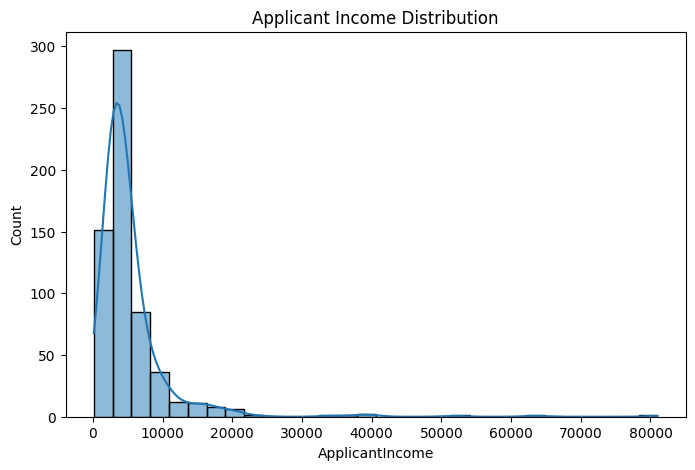

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["ApplicantIncome"],
    bins=30,
    kde=True
)

plt.title("Applicant Income Distribution")
plt.show()


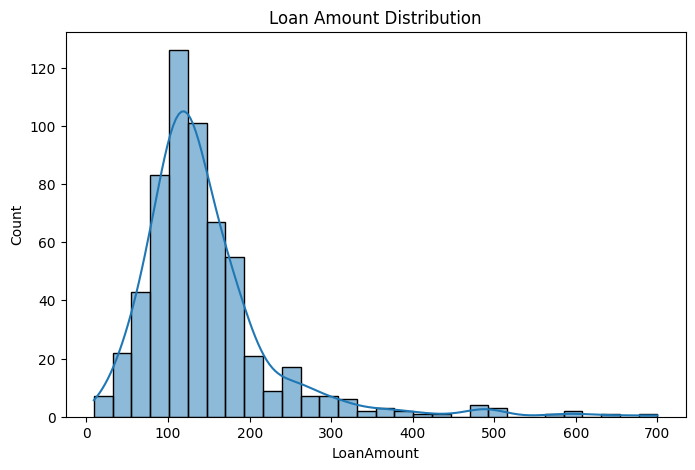

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["LoanAmount"],
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.show()

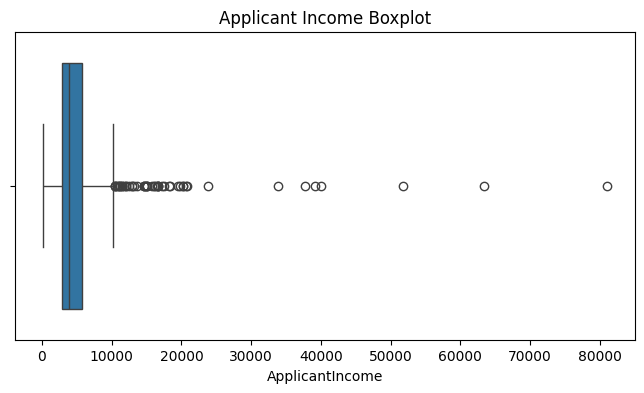

In [30]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["ApplicantIncome"]
)

plt.title("Applicant Income Boxplot")
plt.show()


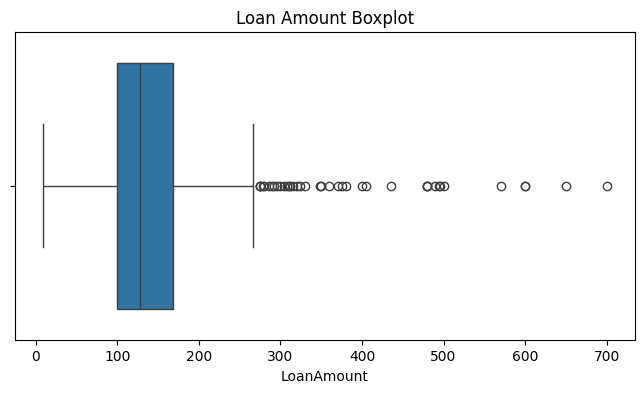

In [31]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["LoanAmount"]
)

plt.title("Loan Amount Boxplot")
plt.show()

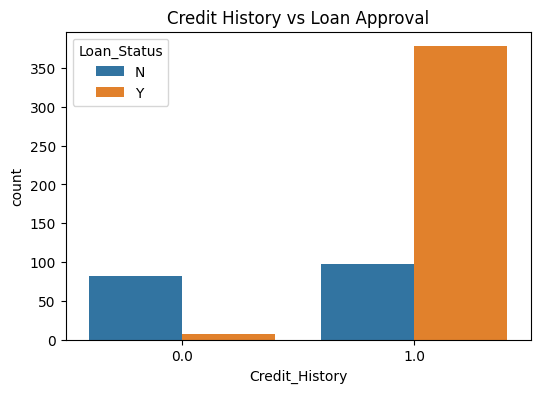

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)

plt.title("Credit History vs Loan Approval")

plt.show()

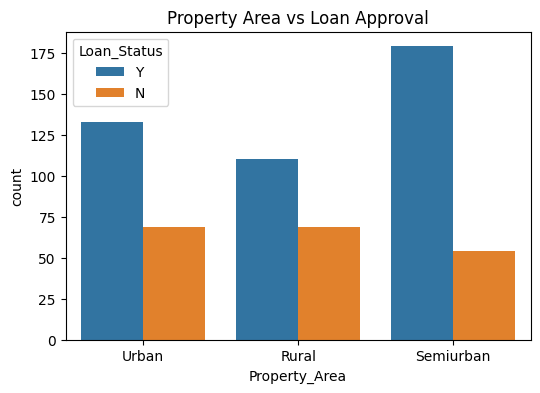

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Property_Area",
    hue="Loan_Status",
    data=df
)

plt.title("Property Area vs Loan Approval")

plt.show()

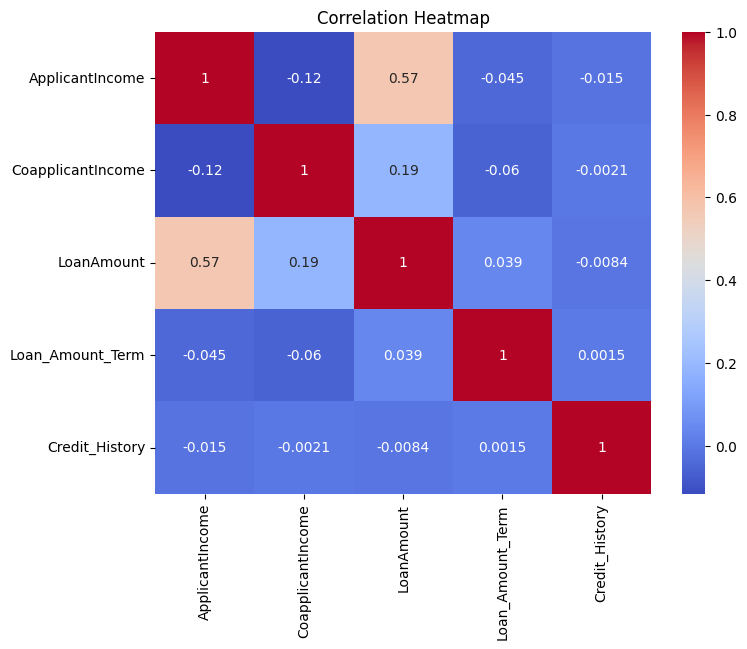

In [34]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()